# Equal1 State Tomography Trial

The aim of this notebook is to implement the procedures to simulate standard indirect quantum state tomography and QELM state tomography on the inaccessible register qubit in the hardware produced by Equal1. The goal is to establish if QELM state tomography can out-perform the standard indirect procedure and if so, what the requirements on training data are to overcome the inaccuracies associated with state preparation.

## 1. Imports

In [1]:
import numpy as np
import scipy

from qsim.lin_alg import sigmaX, sigmaY, sigmaZ, Operator, I

from qsim.state import DensityMatrix, POVMDetector

import matplotlib.pyplot as plt
from tqdm.auto import tqdm

## 2. Model Setup

In [2]:
def sqrt_density_matrix(rho):
    vals, vecs = np.linalg.eigh(rho)

    # Clip tiny negatives from numerical noise
    vals = np.clip(vals, 0, None)

    sqrt_vals = np.sqrt(vals)
    return vecs @ np.diag(sqrt_vals) @ vecs.conj().T

In [3]:
def haar_random_unitary(N):
    # Step 1: random complex Gaussian matrix
    Z = (np.random.randn(N, N) + 1j * np.random.randn(N, N)) / np.sqrt(2)

    # Step 2: QR decomposition
    Q, R = np.linalg.qr(Z)

    # Step 3: fix phases
    diag = np.diag(R)
    phases = diag / np.abs(diag)
    U = Q @ np.diag(phases)

    return U

In [4]:
def generateNoisyGate(gate: Operator, epsilon: float) -> Operator:
    U = Operator(haar_random_unitary(gate.matrix.shape[0]))
    U_herm = 0.5 * (U + U.hConj())
    return Operator(scipy.linalg.expm(-1j*epsilon*U_herm.matrix)) @ gate

In [5]:
def gateFidelity(gate1: Operator, gate2: Operator) -> float:
    d=gate1.matrix.shape[0]
    return (np.abs((gate1.hConj() @ gate2).trace())**2 + d)/(d**2 + d)

In [6]:
gate = Operator(np.eye(2))
gate=sigmaX
strengths = np.linspace(0, np.pi, 200)

fids1 = []
vars1 = []

for strength in strengths:
    noisy_gates = [generateNoisyGate(gate, strength) for i in range(100)]
    gate_fids = [gateFidelity(gate, noisy_gate) for noisy_gate in noisy_gates]
    fids1.append(np.mean(gate_fids))
    vars1.append(np.std(gate_fids))



In [7]:
gate = Operator(np.eye(2))
gate=sigmaX.tensor(sigmaX)
strengths = np.linspace(0, np.pi, 200)

fids2 = []
vars2 = []

for strength in strengths:
    noisy_gates = [generateNoisyGate(gate, strength) for i in range(100)]
    gate_fids = [gateFidelity(gate, noisy_gate) for noisy_gate in noisy_gates]
    fids2.append(np.mean(gate_fids))
    vars2.append(np.std(gate_fids))



Text(0.16, 0.35, '$\\varepsilon = 0.111$, FID=99.5%')

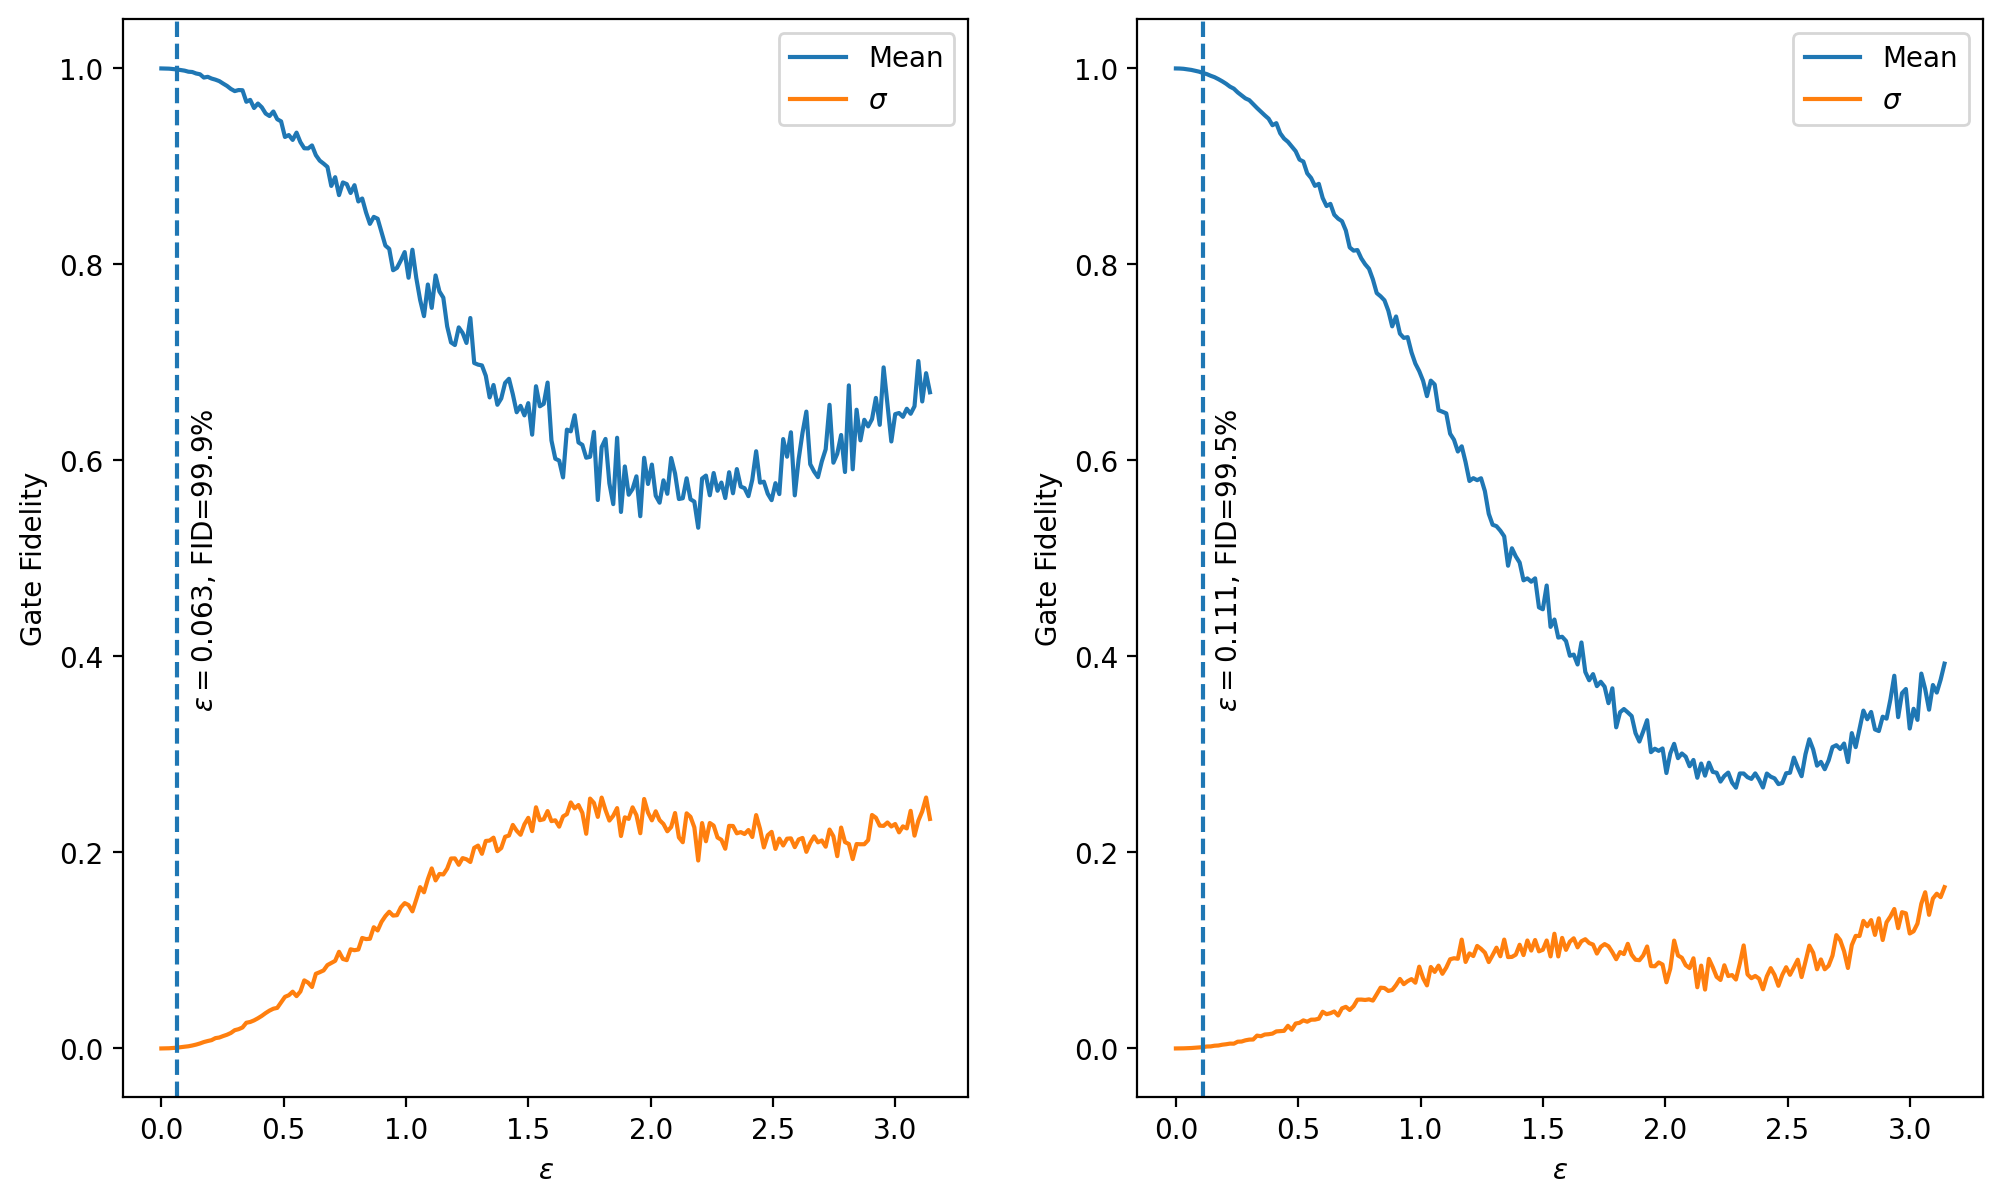

In [8]:
fig, axs = plt.subplots(ncols=2, dpi=200, figsize=(12,7))
ax1 = axs[0]
ax1.plot(strengths, fids1)
ax1.plot(strengths, vars1)
ax1.set_xlabel(r'$\varepsilon$')
ax1.set_ylabel('Gate Fidelity')
ax1.legend(['Mean', r'$\sigma$'])
ax1.axvline(strengths[4], linestyle='--')
ax1.text(x = 0.12, y=0.35, s=r'$\varepsilon = ' + str(np.round(strengths[4], 3)) + r'$, FID=99.9%', rotation=90)

ax2 = axs[1]
ax2.plot(strengths, fids2)
ax2.plot(strengths, vars2)
ax2.set_xlabel(r'$\varepsilon$')
ax2.set_ylabel('Gate Fidelity')
ax2.legend(['Mean', r'$\sigma$'])
ax2.axvline(strengths[7], linestyle='--')
ax2.text(x = 0.16, y=0.35, s=r'$\varepsilon = ' + str(np.round(strengths[7], 3)) + r'$, FID=99.5%', rotation=90)


In [9]:
def generateNoisyState(state: DensityMatrix, epsilon: float) -> DensityMatrix:
    U = Operator(haar_random_unitary(state.matrix.shape[0]))
    U_herm = 0.5 * (U + U.hConj())
    R = Operator(scipy.linalg.expm(-1j*epsilon*U_herm.matrix))
    return R @ state @ R.hConj()

def generateNoisyRegister(epsilon: float) -> DensityMatrix:
    state = DensityMatrix(np.array([[1,0],[0,0]]))
    state_noiy1 = generateNoisyState(state, epsilon)
    state_noiy2 = generateNoisyState(state, epsilon)
    state_noiy3 = generateNoisyState(state, epsilon)
    state_noiy4 = generateNoisyState(state, epsilon)
    return state_noiy1 ^ state_noiy2 ^ state_noiy3 ^ state_noiy4

def generateThermalRegister(T: float) -> DensityMatrix:
    beta = 1/T
    state = DensityMatrix(scipy.linalg.expm(beta * np.array([[1,0],[0,-1]])))
    state = state / state.trace()
    return state ^ state ^ state ^ state

In [10]:
def fidelity(rho1, rho2):
    rho1_sqrt = sqrt_density_matrix(rho1.matrix)
    return np.abs(np.trace(sqrt_density_matrix(rho1_sqrt @ rho2.matrix @ rho1_sqrt)))**2

def mse(rho1, rho2):
    r1 = density_to_bloch(rho1)
    r2 = density_to_bloch(rho2)
    return np.mean((r1 - r2)**2)


In [11]:
target_register = np.zeros((16,16))
target_register[0][0]=1
target_register = DensityMatrix(target_register)
strengths = np.linspace(0, np.pi, 100)

fids = []
vars = []

for strength in tqdm(strengths):
    noisy_states = [generateNoisyRegister(strength) for i in range(100)]
    state_fids = [fidelity(target_register, state) for state in noisy_states]
    fids.append(np.mean(state_fids))
    vars.append(np.std(state_fids))



  0%|          | 0/100 [00:00<?, ?it/s]

Text(0.38, 0.35, '$\\varepsilon = 0.349$, FID=91.5%')

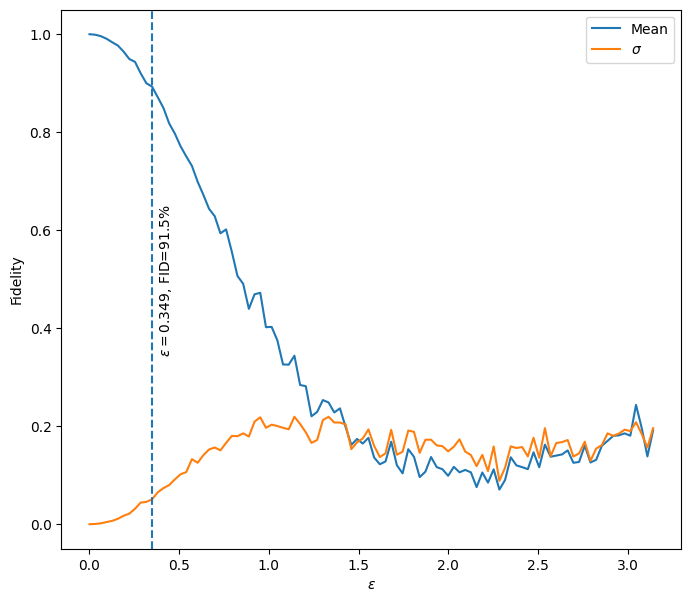

In [12]:
fig, ax = plt.subplots(ncols=1, dpi=100, figsize=(8,7))
ax.plot(strengths, fids)
ax.plot(strengths, vars)
ax.set_xlabel(r'$\varepsilon$')
ax.set_ylabel('Fidelity')
ax.legend(['Mean', r'$\sigma$'])
ax.axvline(strengths[11], linestyle='--')
ax.text(x = 0.38, y=0.35, s=r'$\varepsilon = ' + str(np.round(strengths[11], 3)) + r'$, FID=91.5%', rotation=90)

## 3. Indirect QST

In [46]:
e0 = 0.01
e1 = 0.03

povm1 = Operator(np.array([[1-e0,0],[0,e1]]))
povm2 = Operator(np.array([[e0,0],[0,1-e1]]))

def circuit(left_circ, right_circ, shots=1):
    circ = left_circ ^ right_circ
    det = POVMDetector(povm=[povm1^povm1, povm1^povm2, povm2^povm1, povm2^povm2], outcomes=[1, -1, -1, 1], dims=(2,2,2,2), target_sites=(0,3))
    def measure(state):
        return det.detect(circ@state @ circ.hConj(), shots= shots)
    return measure

def circuit_with_outcomes(left_circ, right_circ, shots=1):
    circ = left_circ ^ right_circ
    det = POVMDetector(povm=[povm1^povm1, povm1^povm2, povm2^povm1, povm2^povm2], outcomes=[1, -1, -1, 1], dims=(2,2,2,2), target_sites=(0,3))
    def measure(state):
        state = circ@state @ circ.hConj()
        val = det.detect(state, shots= 1)
        adj_val = (val + 1)/2
        n_minus = int(shots * adj_val)
        n_plus = int(shots * (1-adj_val))
        return [-1 for i in range(n_minus)] + [1 for i in range(n_plus)]
    return measure


def sigmaXcircuitRight(H, CNOT):
    return CNOT @ H.tensor(I(2))

def sigmaXcircuitLeft(H, CNOT):
    return CNOT @ I(2).tensor(H)

def sigmaYcircuitRight(S, H, CNOT):
    return  CNOT @ H.tensor(I(2)) @ S.hConj().tensor(I(2))

def sigmaYcircuitLeft(S, H, CNOT, shots=1):
    return  CNOT @ I(2).tensor(H) @ I(2).tensor(S.hConj())

def sigmaZcircuitRight(CNOT):
    return CNOT

def sigmaZcircuitLeft(CNOT):
    return CNOT


In [47]:
def density_to_bloch(state: DensityMatrix) -> np.array:
    left_circs = [I(2), sigmaX,  sigmaY, sigmaZ]
    return np.array([((left ^ right) @ state).trace().real for left, right in list(product(left_circs, left_circs))[1:]])

def bloch_to_density(r: np.ndarray) -> DensityMatrix:
    
    sigma = [I(2), sigmaX, sigmaY, sigmaZ]

    components = [r_val * (sig[0]^sig[1]) for r_val, sig in zip(r, list(product(sigma, sigma))[1:])]
    return 0.25 * sum(components) 

In [48]:
from itertools import product
from math import e

import scipy.optimize

#def register_func():
#    return generateNoisyRegister(0.349)

def register_func():
    return generateThermalRegister(0.56)

def indirect_tomography(U, shots, H, S, CNOT_left, CNOT_right, circuit_shots=1):

    left_circs = [I(4), sigmaXcircuitLeft(H, CNOT_left),  sigmaYcircuitLeft(S, H, CNOT_left), sigmaZcircuitLeft(CNOT_left)]
    right_circs = [I(4), sigmaXcircuitRight(H, CNOT_right),  sigmaYcircuitRight(S, H, CNOT_right), sigmaZcircuitRight(CNOT_right)]
    circs = [circuit(left, right, circuit_shots) for left, right in list(product(left_circs, right_circs))[1:]]

    r = [[] for i in range(len(circs))]

    for i in (range(shots)):
        for j, circ in enumerate(circs):
            r[j].append(circ(U @ register_func() @ U.hConj()))

    r = np.mean(r, axis=1)
    return r

def params_to_T(params):
    """
    Convert real parameter vector into 4x4 complex lower-triangular matrix T
    """
    T = np.zeros((4, 4), dtype=complex)
    idx = 0

    for i in range(4):
        for j in range(i + 1):
            if i == j:
                T[i, j] = params[idx]
                idx += 1
            else:
                T[i, j] = params[idx] + 1j * params[idx + 1]
                idx += 2

    return T


def params_to_rho(params):
    T = params_to_T(params)
    rho = T @ T.conj().T
    return rho / np.trace(rho)

def indirect_tomography_mle(U, H, S, CNOT_left, CNOT_right, circuit_shots = 1):
    print('start')
    left_circs = [I(4), sigmaXcircuitLeft(H, CNOT_left),  sigmaYcircuitLeft(S, H, CNOT_left), sigmaZcircuitLeft(CNOT_left)]
    right_circs = [I(4), sigmaXcircuitRight(H, CNOT_right),  sigmaYcircuitRight(S, H, CNOT_right), sigmaZcircuitRight(CNOT_right)]
    circs = [circuit_with_outcomes(left, right, circuit_shots) for left, right in list(product(left_circs, right_circs))[1:]]

    r = [[] for i in range(len(circs))]

    for j, circ in enumerate(circs):
        r[j].append(circ(U @ register_func() @ U.hConj()))

    r_counts = [[0,0] for i in circs]
    r_values = [np.unique_counts(row) for row in r]

    for i in range(len(r)):
        for val, count in zip(r_values[i].values, r_values[i].counts):
            if val == -1:
                r_counts[i][0] = count
            else:
                r_counts[i][1] = count

    def neg_log_likelihood(x, r_counts):
        rho = DensityMatrix(params_to_rho(x))
        r = density_to_bloch(rho)
        r_ps = np.array([[1-r[i], 1+r[i]] for i in range(len(r))])/2
        neg_likelihood = -sum([r_counts[i][0] * np.log(r_ps[i][0]) + r_counts[i][1] * np.log(r_ps[i][1]) for i in range(len(r))])
        return neg_likelihood

    print('minimising')
    res = scipy.optimize.minimize(lambda x: neg_log_likelihood(x, r_counts), x0 = np.array([1 for i in range(16)]))
    return res.x


In [49]:
H = Operator(np.array([[1,1],[1,-1]])/(2**0.5))
S = Operator(np.array([[1,0],[0,1j]]))
CNOT_right = Operator(np.array([[1,0,0,0],[0,1,0,0],[0,0,0,1],[0,0,1,0]]))
CNOT_left = Operator(np.array([[1,0,0,0],[0,0,0,1],[0,0,1,0],[0,1,0,0]]))

In [50]:
noisy_S = generateNoisyGate(S, epsilon=0.063)
noisy_H = generateNoisyGate(H, epsilon=0.063)
noisy_CNOT_right = generateNoisyGate(CNOT_right, epsilon=0.111)
noisy_CNOT_left = generateNoisyGate(CNOT_left, epsilon=0.111)

In [51]:
n_states = 10
Us = [I(2) ^ Operator(haar_random_unitary(4)) ^ I(2) for i in range(n_states)]

In [52]:
targets = [(U @ generateNoisyRegister(0) @ U.hConj()).partialTrace(dims=(2,2,2,2), reduce_to_sites=(1,2)) for U in Us]

In [53]:
shots = (10**np.linspace(0,8, 10)).astype(int)
shots

array([        1,         7,        59,       464,      3593,     27825,
          215443,   1668100,  12915496, 100000000])

In [54]:

trials = 1
fids = []
vars = []

for shot in tqdm(shots):
    fid_trials = []
    for trial in range(trials):
        for U, target in zip(Us, targets):
            #r = indirect_tomography(U, 1, noisy_H, noisy_S, noisy_CNOT_left, noisy_CNOT_right, circuit_shots=shot)
            r = indirect_tomography_mle(U, noisy_H, noisy_S, noisy_CNOT_left, noisy_CNOT_right, circuit_shots=shot)
            est_state = DensityMatrix(params_to_rho(r))
            fid_trials.append(fidelity(target, est_state))
    fids.append(np.mean(fid_trials))
    vars.append(np.std(fid_trials))

  0%|          | 0/10 [00:00<?, ?it/s]

start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimising
start
minimisi

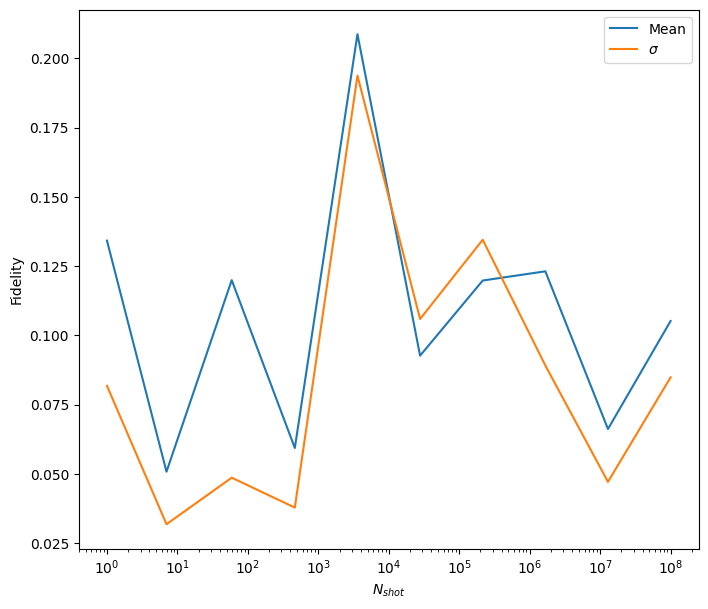

In [55]:
fig, ax = plt.subplots(ncols=1, dpi=100, figsize=(8,7))
ax.plot(shots, fids)
ax.plot(shots, vars)
ax.set_xlabel(r'$N_{shot}$')
ax.set_ylabel('Fidelity')
ax.legend(['Mean', r'$\sigma$'])
ax.set_xscale('log')

## QELM QST

In [1]:
def rz_gate(theta):
    return Operator(np.array([[np.exp(-1j*theta/2),0],[0,np.exp(1j*theta/2)]]))

def ry_gate(theta):
    return Operator(np.array([[np.cos(theta/2),-np.sin(theta/2)],[np.sin(theta/2),np.cos(theta/2)]]))

In [ ]:
def training_data_rotations(z_angles: np.ndarray, y_angles: np.ndarray, z_gates: dict, y_gates: dict):
    rotations = []

    for theta_y in y_angles:
        if theta_y == 0 or theta_y == np.pi:
            rotations.append(y_gates[theta_y])
        else:
            for theta_z in z_angles:
                rotations.append(z_gates[theta_z] @ y_gates[theta_y])
    
    comp_rotations = []
    for r1 in rotations:
        for r2 in rotations:
            comp_rotations.append(r1 ^ r2)

    return comp_rotations


In [ ]:
def training_data_rotations_from_angles(z_angles: np.ndarray, y_angles: np.ndarray):
    z_gates = {z: rz_gate(z) for z in z_angles}
    y_gates = {y: ry_gate(y) for y in y_angles}

    z_gates_noisy = {z: generateNoisyGate(rz_gate(z), 0.063) for z in z_angles}
    y_gates_noisy = {y: generateNoisyGate(ry_gate(y), 0.063) for y in y_angles}

    rotations = training_data_rotations(z_angles, y_angles, z_gates, y_gates)
    noisy_rotations = training_data_rotations(z_angles, y_angles, z_gates_noisy, y_gates_noisy)

    return rotations, noisy_rotations

In [ ]:
z_angles1 = np.linspace(0, 2*np.pi, 5)[:-1]
y_angles1 = np.linspace(0, np.pi, 3)

z_angles2 = np.linspace(0, 2*np.pi, 9)[:-1]
y_angles2 = np.linspace(0, np.pi, 5)

z_angles3 = np.linspace(0, 2*np.pi, 13)[:-1]
y_angles3 = np.linspace(0, np.pi, 7)

rotations1, noisy_rotations1 = training_data_rotations_from_angles(z_angles1, y_angles1)
states1 = [r @ DensityMatrix(np.array([[1,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]])) @ r.hConj() for r in rotations1]

rotations2, noisy_rotations2 = training_data_rotations_from_angles(z_angles2, y_angles2)
states2 = [r @ DensityMatrix(np.array([[1,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]])) @ r.hConj() for r in rotations2]

rotations3, noisy_rotations3 = training_data_rotations_from_angles(z_angles3, y_angles3)
states3 = [r @ DensityMatrix(np.array([[1,0,0,0],[0,0,0,0],[0,0,0,0],[0,0,0,0]])) @ r.hConj() for r in rotations3]

In [ ]:
from qres import regression
from sklearn.linear_model import LinearRegression

def QELM_tomography(H, S, CNOT_left, CNOT_right, training_states, noisy_training_circuits, regression_shots, circuit_shots=1):
    left_circs = [I(4), sigmaXcircuitLeft(H, CNOT_left),  sigmaYcircuitLeft(S, H, CNOT_left), sigmaZcircuitLeft(CNOT_left)]
    right_circs = [I(4), sigmaXcircuitRight(H, CNOT_right),  sigmaYcircuitRight(S, H, CNOT_right), sigmaZcircuitRight(CNOT_right)]
    circs = [circuit(left, right, circuit_shots) for left, right in list(product(left_circs, right_circs))[1:]]

    x_tr = []
    y_tr = []

    for state, noisy_circuit in (zip(training_states, noisy_training_circuits)):
        full_circuit = I(2) ^ noisy_circuit ^ I(2)
        
        r = [[] for i in range(len(circs))]

        for i in (range(np.max(regression_shots))):
            for j, circ in enumerate(circs):
                r[j].append(circ(full_circuit @ register_func() @ full_circuit.hConj()))
        x_tr.append(r)
        y_tr.append(density_to_bloch(state))

    regs = []

    for shots in regression_shots:
        reg = LinearRegression()
        x_tr_reduced = np.array([[np.mean(row[:shots]) for row in tr] for tr in x_tr])
        reg.fit(x_tr_reduced, y_tr)
        regs.append(reg)

    return regs

def apply_QELM_tomography(U, H, S, CNOT_left, CNOT_right, reg, shots, circuit_shots=1):
    left_circs = [I(4), sigmaXcircuitLeft(H, CNOT_left),  sigmaYcircuitLeft(S, H, CNOT_left), sigmaZcircuitLeft(CNOT_left)]
    right_circs = [I(4), sigmaXcircuitRight(H, CNOT_right),  sigmaYcircuitRight(S, H, CNOT_right), sigmaZcircuitRight(CNOT_right)]
    circs = [circuit(left, right, circuit_shots) for left, right in list(product(left_circs, right_circs))[1:]]
    
    r = [np.mean([circ(U @ register_func() @ U.hConj()) for i in range(shots)]) for circ in circs]
    r = reg.predict(np.array(r).reshape(1,-1))[0]
    #if np.sum(r**2).real > 1:
    #    return r/np.sum(r**2).real
    #else:
    return r

In [ ]:


regs1 = [[QELM_tomography(noisy_H, noisy_S, noisy_CNOT_left, noisy_CNOT_right, states1, noisy_rotations1, [1], shot)[0] for shot in shots] for trial in tqdm(range(trials))]
regs2 = [[QELM_tomography(noisy_H, noisy_S, noisy_CNOT_left, noisy_CNOT_right, states2, noisy_rotations2, [1], shot)[0] for shot in shots] for trial in tqdm(range(trials))]
#regs3 = [[QELM_tomography(noisy_H, noisy_S, noisy_CNOT_left, noisy_CNOT_right, states3, noisy_rotations3, [1], shot)[0] for shot in shots] for trial in tqdm(range(trials))]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
import numpy as np

def project_to_physical(rho):
    # Hermitise first (important!)
    rho = (rho + rho.conj().T) / 2

    vals, vecs = np.linalg.eigh(rho)

    # Clip negative eigenvalues
    vals = np.clip(vals, 0, None)

    # Renormalise
    if np.sum(vals) == 0:
        # fallback: maximally mixed
        vals = np.ones_like(vals) / len(vals)
    else:
        vals /= np.sum(vals)

    rho_phys = vecs @ np.diag(vals) @ vecs.conj().T
    return rho_phys

In [ ]:
fids_qelm1 = []
vars_qelm1 = []

fids_qelm2 = []
vars_qelm2 = []

fids_qelm3 = []
vars_qelm3 = []

for i, shot in (enumerate(tqdm(shots))):
    fid_trials1 = []
    fid_trials2 = []
    fid_trials3 = []
    for j, trial in enumerate(range(trials)):
        reg1 = regs1[j][i]
        reg2 = regs2[j][i]
        #reg3 = regs3[j][i]
        for U, target in zip(Us, targets):
            est_state1 = bloch_to_density(apply_QELM_tomography(U, noisy_H, noisy_S, noisy_CNOT_left, noisy_CNOT_right, reg1, 1, shot))
            est_state1 = DensityMatrix(project_to_physical(est_state1.matrix))
            est_state2 = bloch_to_density(apply_QELM_tomography(U, noisy_H, noisy_S, noisy_CNOT_left, noisy_CNOT_right, reg2, 1, shot))
            est_state2 = DensityMatrix(project_to_physical(est_state2.matrix))
        #    est_state3 = bloch_to_density(apply_QELM_tomography(U, noisy_H, noisy_S, noisy_CNOT_left, noisy_CNOT_right, reg3, 1, shot))
            fid_trials1.append(fidelity(target, est_state1))
            fid_trials2.append(fidelity(target, est_state2))
        #    fid_trials3.append(fidelity(target, est_state3))
    fids_qelm1.append(np.mean(fid_trials1))
    vars_qelm1.append(np.std(fid_trials1))
    fids_qelm2.append(np.mean(fid_trials2))
    vars_qelm2.append(np.std(fid_trials2))
    #fids_qelm3.append(np.mean(fid_trials3))
    #vars_qelm3.append(np.std(fid_trials3))

  0%|          | 0/10 [00:00<?, ?it/s]

In [ ]:
apply_QELM_tomography(U, noisy_H, noisy_S, noisy_CNOT_left, noisy_CNOT_right, reg2, 1, shot)

array([-0.06862201, -0.17961356,  0.32882066, -0.33158036,  0.72639207,
        0.48277948, -0.59632133,  0.10740491,  0.34300922, -0.88173457,
       -0.26211274,  0.19969603,  0.51541159, -0.05383881,  0.72570121])

In [ ]:
density_to_bloch(target)

array([-0.0699746 , -0.20894747,  0.34740972, -0.32812857,  0.67376413,
        0.41199689, -0.56099894,  0.07744697,  0.28924435, -0.83861298,
       -0.22319277,  0.23575965,  0.54591854, -0.03737489,  0.76610031])

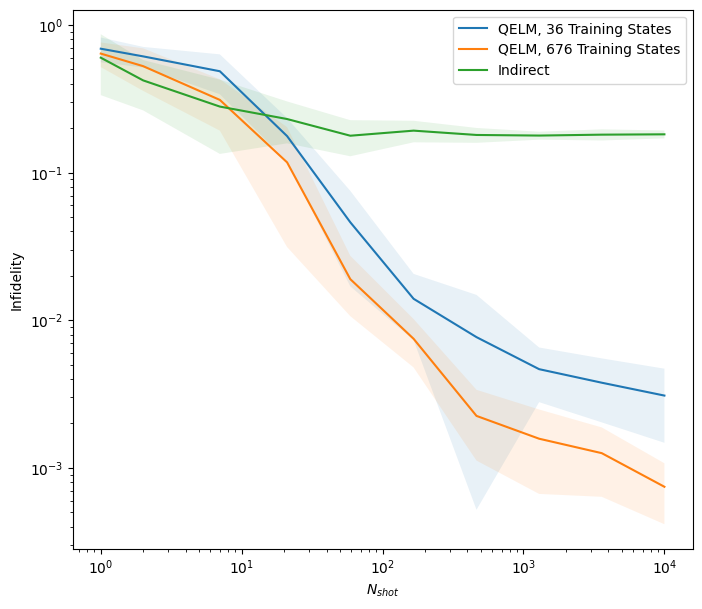

In [ ]:
fids_qelm1 = np.array(fids_qelm1)
fids_qelm2 = np.array(fids_qelm2)
fids_qelm3 = np.array(fids_qelm3)
fids = np.array(fids)

vars_qelm1 = np.array(vars_qelm1)
vars_qelm2 = np.array(vars_qelm2)
vars_qelm3 = np.array(vars_qelm3)
vars = np.array(vars)

fig, ax = plt.subplots(ncols=1, dpi=100, figsize=(8,7))
ax.plot(shots, 1-fids_qelm1, label=f'QELM, {len(states1)} Training States')
ax.fill_between(shots, 1-(np.array(fids_qelm1) - np.array(vars_qelm1)), 1-(np.array(fids_qelm1) + np.array(vars_qelm1)), alpha=0.1)
ax.plot(shots, 1-fids_qelm2, label=f'QELM, {len(states2)} Training States')
ax.fill_between(shots, 1-(np.array(fids_qelm2) - np.array(vars_qelm2)), 1-(np.array(fids_qelm2) + np.array(vars_qelm2)), alpha=0.1)
#ax.plot(shots, 1-fids_qelm3, label=f'QELM, {len(states3)} Training States')
#ax.fill_between(shots, 1-(np.array(fids_qelm3) - np.array(vars_qelm3)), 1-(np.array(fids_qelm3) + np.array(vars_qelm3)), alpha=0.1)
ax.plot(shots, 1-fids, label='Indirect')
ax.fill_between(shots, 1-(np.array(fids) - np.array(vars)), 1-(np.array(fids) + np.array(vars)), alpha=0.1)
ax.set_xlabel(r'$N_{shot}$')
ax.set_ylabel('Infidelity')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')

In [ ]:
vars_qelm2

array([0.12163929, 0.16847899, 0.11840726, 0.08613916, 0.00833476,
       0.00269941, 0.00112957, 0.00091058, 0.0006217 , 0.00032984])

In [ ]:
np.array(fids_qelm2)

array([0.35915944, 0.47340102, 0.68889229, 0.88250993, 0.98099963,
       0.9925064 , 0.99774879, 0.99842283, 0.99874098, 0.99925456])

In [ ]:
vars

array([0.26571561, 0.15760166, 0.14640268, 0.07289233, 0.04878541,
       0.03204265, 0.02078839, 0.01105769, 0.01567329, 0.01115592])

In [ ]:
fids

array([0.87924243, 0.88817328, 0.30321562, 0.1532137 , 0.09084758,
       0.05714861, 0.03411745, 0.02450368, 0.0187119 , 0.01529699,
       0.01375849, 0.01287304, 0.01253287, 0.01161546, 0.01177992,
       0.01174669, 0.01172586, 0.01170316, 0.01164247, 0.01167462])